# ML Inference Energy Consumption Analysis

Compares energy-per-inference for two frameworks on ESP32:
- **AIfES** (float32, Fraunhofer IMS)
- **TF Lite Micro** (INT8 quantised, Google)

Same network: `Input(10) → Dense(16, ReLU) → Dense(1, Sigmoid)` — 193 parameters.

## PPK2 Data Location
```
C:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\ML\
    AlfES_Inference\    ← 3 CSV files (Test1.csv, Test2.csv, Test3.csv)
    Tensorflow_Lite\    ← 3 CSV files (Test1.csv, Test2.csv, Test3.csv)
```

## Measurement Protocol
- N_REPEATS = 100, N_TEST = 332 → **33,200 inferences per run**
- LED on GPIO2 is HIGH during the benchmark window only
- Supply voltage: 5V (USB wall charger through PPK2)
- PPK2 sample rate: 100,000 samples/second
- Window duration: ~2.3s (AIfES) | ~3.3s (TFLM)

**Energy per inference = (energy in window [µJ]) / 33,200**

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ---------------------------------------------------------------------------
# Paths — PPK2 data lives outside the repo
# ---------------------------------------------------------------------------
DATA_DIR     = Path(r'C:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\ML')
AIFES_DIR    = DATA_DIR / 'AlfES_Inference'
TFLM_DIR     = DATA_DIR / 'Tensorflow_Lite'

# Results (plots + CSV summary) saved back into the repo next to this notebook
RESULTS_DIR  = Path('ppk2_results')
RESULTS_DIR.mkdir(exist_ok=True)

N_INFERENCES = 33_200   # 100 repeats x 332 test samples
V_SUPPLY     = 5.0      # Volts — USB wall charger

print(f'AIfES data : {AIFES_DIR}')
print(f'TFLM data  : {TFLM_DIR}')
print(f'Results    : {RESULTS_DIR.resolve()}')
print(f'Inferences per run: {N_INFERENCES:,}')

# Sanity-check folders exist
for d, name in [(AIFES_DIR, 'AIfES'), (TFLM_DIR, 'TFLM')]:
    if d.exists():
        csvs = list(d.glob('*.csv'))
        print(f'  {name}: {len(csvs)} CSV files found — {[f.name for f in csvs]}')
    else:
        print(f'  WARNING: {name} folder not found at {d}')

AIfES data : C:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\ML\AlfES_Inference
TFLM data  : C:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\ML\Tensorflow_Lite
Results    : C:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\Code\Thesis-Edge-AI\ML_Training\ppk2_results
Inferences per run: 33,200
  AIfES: 3 CSV files found — ['Test1.csv', 'Test2.csv', 'Test3.csv']
  TFLM: 3 CSV files found — ['Test1.csv', 'Test2.csv', 'Test3.csv']


## 1. Helper Functions

Load PPK2 CSV files, detect the benchmark window from the current step-up, and
compute energy by integrating I × V × dt.

**Timestamp fix**: PPK2 exports in milliseconds (t_max ≈ 10,000 ms). The old code
compared `t_max > 1e6` for the ms branch — since 10,000 < 1,000,000 this always fell
through, treating 10,000 ms as 10,000 seconds. Fixed to `t_max > 100`.

**Window detection**: The ESP32 benchmark raises current ~25% above idle during inference.
`threshold_factor=1.15` safely detects this without overshooting.
`smooth_window=5000` = 50 ms at 100 kHz removes switching noise.

In [22]:
def load_ppk2_csv(path: Path) -> pd.DataFrame:
    """
    Load a PPK2 export CSV (nRF Power Profiler format).
    Returns DataFrame with columns: time_s, current_uA
    """
    path = Path(path)

    # Find the header row (skip any PPK2 metadata)
    header_row = 0
    with open(path, 'r', errors='replace') as f:
        for i, line in enumerate(f):
            low = line.strip().lower()
            if any(k in low for k in ['timestamp', 'time', 'current', 'sample']):
                header_row = i
                break
            if line.strip() and line.strip()[0].isdigit():
                header_row = None
                break

    if header_row is not None:
        df = pd.read_csv(path, skiprows=header_row, on_bad_lines='skip')
    else:
        df = pd.read_csv(path, header=None, on_bad_lines='skip')

    df.columns = [str(c).strip().lower().replace(' ', '_') for c in df.columns]
    print(f'  Loaded {len(df):,} rows. Columns: {list(df.columns)}')

    time_col    = next((c for c in df.columns if 'time' in c or 'stamp' in c), df.columns[0])
    current_col = next((c for c in df.columns if 'current' in c or 'ua' in c or 'amp' in c), df.columns[1])

    df = df[[time_col, current_col]].copy()
    df.columns = ['timestamp_raw', 'current_uA']
    df['current_uA']    = pd.to_numeric(df['current_uA'],    errors='coerce')
    df['timestamp_raw'] = pd.to_numeric(df['timestamp_raw'], errors='coerce')
    df = df.dropna()

    # ------------------------------------------------------------------
    # Timestamp unit detection (fixed — old code used wrong thresholds)
    #
    # For a ~10 second recording:
    #   microseconds : t_max ~ 10,000,000   →  > 1,000,000
    #   milliseconds : t_max ~     10,000   →  > 100  (was wrongly > 1e6)
    #   seconds      : t_max ~         10   →  ≤ 100
    # ------------------------------------------------------------------
    t_max = df['timestamp_raw'].max()
    if t_max > 1_000_000:
        df['time_s'] = df['timestamp_raw'] / 1e6
        unit = 'us'
    elif t_max > 100:
        df['time_s'] = df['timestamp_raw'] / 1e3
        unit = 'ms'
    else:
        df['time_s'] = df['timestamp_raw'].astype(float)
        unit = 's'

    df = df.sort_values('time_s').reset_index(drop=True)
    duration    = df['time_s'].iloc[-1] - df['time_s'].iloc[0]
    sample_rate = len(df) / duration if duration > 0 else 0
    print(f'  Timestamp unit: {unit} | duration: {duration:.2f}s | '
          f'sample rate: {sample_rate:.0f} Hz | '
          f'current mean: {df["current_uA"].mean():.0f} uA  '
          f'min: {df["current_uA"].min():.0f}  max: {df["current_uA"].max():.0f}')

    return df[['time_s', 'current_uA']].reset_index(drop=True)


def detect_benchmark_window(df: pd.DataFrame,
                             idle_percentile=40,
                             threshold_factor=1.15,
                             min_duration=0.5,
                             smooth_window=5000):
    """
    Detect the benchmark window (LED HIGH = inference running) from the current trace.

    Parameters tuned for ESP32 via PPK2 at 100 kHz:
      idle_percentile=40  : robust idle estimate (40th pct of full trace)
      threshold_factor=1.15: benchmark raises current ~25% above idle on ESP32 —
                             1.15x gives a safe margin without overshooting
      smooth_window=5000  : 50 ms smoothing at 100 kHz (filters switching noise)
    """
    current_smooth = df['current_uA'].rolling(
        window=smooth_window, center=True, min_periods=1).mean()

    idle_current = np.percentile(current_smooth, idle_percentile)
    threshold    = idle_current * threshold_factor

    above   = current_smooth > threshold
    changes = above.astype(int).diff().fillna(0)
    starts  = df['time_s'][changes ==  1].values
    ends    = df['time_s'][changes == -1].values

    # If trace ends while still above threshold, add end-of-trace as final end
    if len(starts) > len(ends):
        ends = np.append(ends, df['time_s'].iloc[-1])

    best_start, best_end, best_dur = None, None, 0
    for s in starts:
        valid_ends = ends[ends > s + min_duration]
        if len(valid_ends) == 0:
            continue
        e = valid_ends[0]
        dur = e - s
        if dur > best_dur:
            best_dur, best_start, best_end = dur, s, e

    if best_start is not None:
        print(f'  Window detected: {best_start:.3f}s to {best_end:.3f}s  '
              f'({best_dur:.3f}s)  '
              f'[idle={idle_current:.0f} uA, threshold={threshold:.0f} uA]')
        return float(best_start), float(best_end)

    print(f'  WARNING: Detection failed (idle={idle_current:.0f} uA, '
          f'threshold={threshold:.0f} uA, max={current_smooth.max():.0f} uA). '
          f'Using middle 60% of trace.')
    t0, t1 = df['time_s'].quantile([0.2, 0.8])
    return float(t0), float(t1)


def calc_energy_uJ(df: pd.DataFrame, t_start: float, t_end: float,
                   v_supply: float = V_SUPPLY) -> float:
    """E(uJ) = integral( I(uA) * V(V) * dt(s) )"""
    mask = (df['time_s'] >= t_start) & (df['time_s'] <= t_end)
    seg  = df[mask]
    if len(seg) < 2:
        return 0.0
    dt = np.diff(seg['time_s'].values)
    i  = seg['current_uA'].values[:-1]
    return float(np.sum(i * v_supply * dt))


print('Helper functions loaded.')
print('Timestamp fix: ms threshold lowered from 1e6 to 100.')
print('Detection fix: threshold_factor=1.15, smooth_window=5000 (50ms at 100kHz).')

Helper functions loaded.
Timestamp fix: ms threshold lowered from 1e6 to 100.
Detection fix: threshold_factor=1.15, smooth_window=5000 (50ms at 100kHz).


## 2. Trace Visualisation — Verify Window Detection

Each plot shows the full 10-second PPK2 trace (grey = raw, coloured = smoothed), with the detected inference window shaded in orange. A zoomed panel below shows the step change at the window edges. These should match what you see in the nRF Power Profiler software.

**Check**: the shaded window should align with the clear current step-up and step-down in the trace.

In [23]:
def plot_trace_with_window(fpath, framework='AIfES', run_num=1, color='steelblue'):
    """
    Plot a single PPK2 trace exactly as it looks in the PPK2 software:
    - Full current trace in grey
    - Smoothed trace overlaid in colour
    - Detected benchmark window shaded and annotated
    - Y-axis zoomed to data range so the benchmark 'box' is clearly visible
    """
    df = load_ppk2_csv(fpath)
    t_start, t_end = detect_benchmark_window(df)
    energy_uJ  = calc_energy_uJ(df, t_start, t_end)
    nJ_per_inf = energy_uJ / N_INFERENCES * 1000
    window_s   = t_end - t_start
    us_per_inf = window_s * 1e6 / N_INFERENCES

    # Smooth at 10 ms resolution for plotting (100 samples at 100 kHz)
    smooth = df['current_uA'].rolling(window=10000, center=True, min_periods=1).mean()

    # Compute y-axis limits from the actual data range (not 0-based)
    # This makes the benchmark step visible as a clear rectangular box
    y_lo = df['current_uA'].quantile(0.005)
    y_hi = df['current_uA'].quantile(0.995)
    y_margin = (y_hi - y_lo) * 0.35

    fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                             gridspec_kw={'height_ratios': [3, 1]})

    # ── Top: full trace ──────────────────────────────────────────────────────
    ax = axes[0]
    ds_step = max(1, len(df) // 5000)   # downsample to ~5000 points for speed
    ax.plot(df['time_s'].iloc[::ds_step], df['current_uA'].iloc[::ds_step],
            lw=0.4, color='#aaaaaa', alpha=0.7, label='Raw current')
    ax.plot(df['time_s'].iloc[::ds_step], smooth.iloc[::ds_step],
            lw=1.5, color=color, label='Smoothed (10 ms)')

    ax.axvspan(t_start, t_end, alpha=0.18, color='orange', zorder=0)
    ax.axvline(t_start, color='darkorange', lw=2, ls='--', label=f'Window start {t_start:.3f}s')
    ax.axvline(t_end,   color='darkorange', lw=2, ls='-.',  label=f'Window end {t_end:.3f}s')

    # Idle and active mean lines
    idle_mask   = (df['time_s'] < t_start) | (df['time_s'] > t_end)
    active_mask = (df['time_s'] >= t_start) & (df['time_s'] <= t_end)
    idle_mean   = df.loc[idle_mask,   'current_uA'].mean()
    active_mean = df.loc[active_mask, 'current_uA'].mean()
    ax.axhline(idle_mean,   color='royalblue', lw=1.2, ls=':', alpha=0.8,
               label=f'Idle mean: {idle_mean:.0f} µA')
    ax.axhline(active_mean, color='tomato',    lw=1.2, ls=':', alpha=0.8,
               label=f'Active mean: {active_mean:.0f} µA')

    ax.set_title(f'{framework} — Run {run_num} | {nJ_per_inf:.1f} nJ/inference | '
                 f'{us_per_inf:.1f} µs/inference | window = {window_s:.3f}s',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Current (µA)')
    ax.set_ylim(y_lo - y_margin, y_hi + y_margin)   # zoom to signal range
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.25)

    # ── Bottom: zoomed window ────────────────────────────────────────────────
    ax2 = axes[1]
    pad  = window_s * 0.5
    zoom = df[(df['time_s'] >= t_start - pad) & (df['time_s'] <= t_end + pad)]
    smooth_zoom = zoom['current_uA'].rolling(window=1000, center=True, min_periods=1).mean()
    ax2.plot(zoom['time_s'], zoom['current_uA'], lw=0.3, color='#aaaaaa', alpha=0.6)
    ax2.plot(zoom['time_s'], smooth_zoom,        lw=1.5, color=color)
    ax2.axvspan(t_start, t_end, alpha=0.25, color='orange')
    ax2.axvline(t_start, color='darkorange', lw=2, ls='--')
    ax2.axvline(t_end,   color='darkorange', lw=2, ls='-.')
    ax2.set_title(f'Zoomed: ±{pad:.2f}s around benchmark window')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Current (µA)')
    ax2.set_ylim(y_lo - y_margin, y_hi + y_margin)  # same zoom for consistency
    ax2.grid(True, alpha=0.25)

    plt.suptitle(f'PPK2 Trace — {framework} Run {run_num}   '
                 f'[{Path(fpath).name}]',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    save_path = RESULTS_DIR / f'{framework.lower().replace(" ","_")}_run{run_num}_trace.png'
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'  Energy: {nJ_per_inf:.1f} nJ/inference  |  Latency: {us_per_inf:.1f} µs/inference')
    print(f'  Idle mean: {idle_mean:.0f} µA  →  Active mean: {active_mean:.0f} µA  '
          f'(+{active_mean - idle_mean:.0f} µA, +{(active_mean/idle_mean - 1)*100:.1f}%)')
    print(f'  Saved: {save_path}')
    return {'window_s': window_s, 'energy_uJ': energy_uJ,
            'nJ_per_inf': nJ_per_inf, 'us_per_inf': us_per_inf}

print('plot_trace_with_window() defined.')
print('Run the cells below to visualise each trace and verify the window detection.')

plot_trace_with_window() defined.
Run the cells below to visualise each trace and verify the window detection.



  Loaded 1,000,001 rows. Columns: ['timestamp(ms)', 'current(ua)', 'd0-d7']
  Timestamp unit: ms | duration: 10.00s | sample rate: 100000 Hz | current mean: 6036 uA  min: 1036  max: 11036
  Window detected: 5.791s to 11.036s  (5.245s)  [idle=5036 uA, threshold=5791 uA]


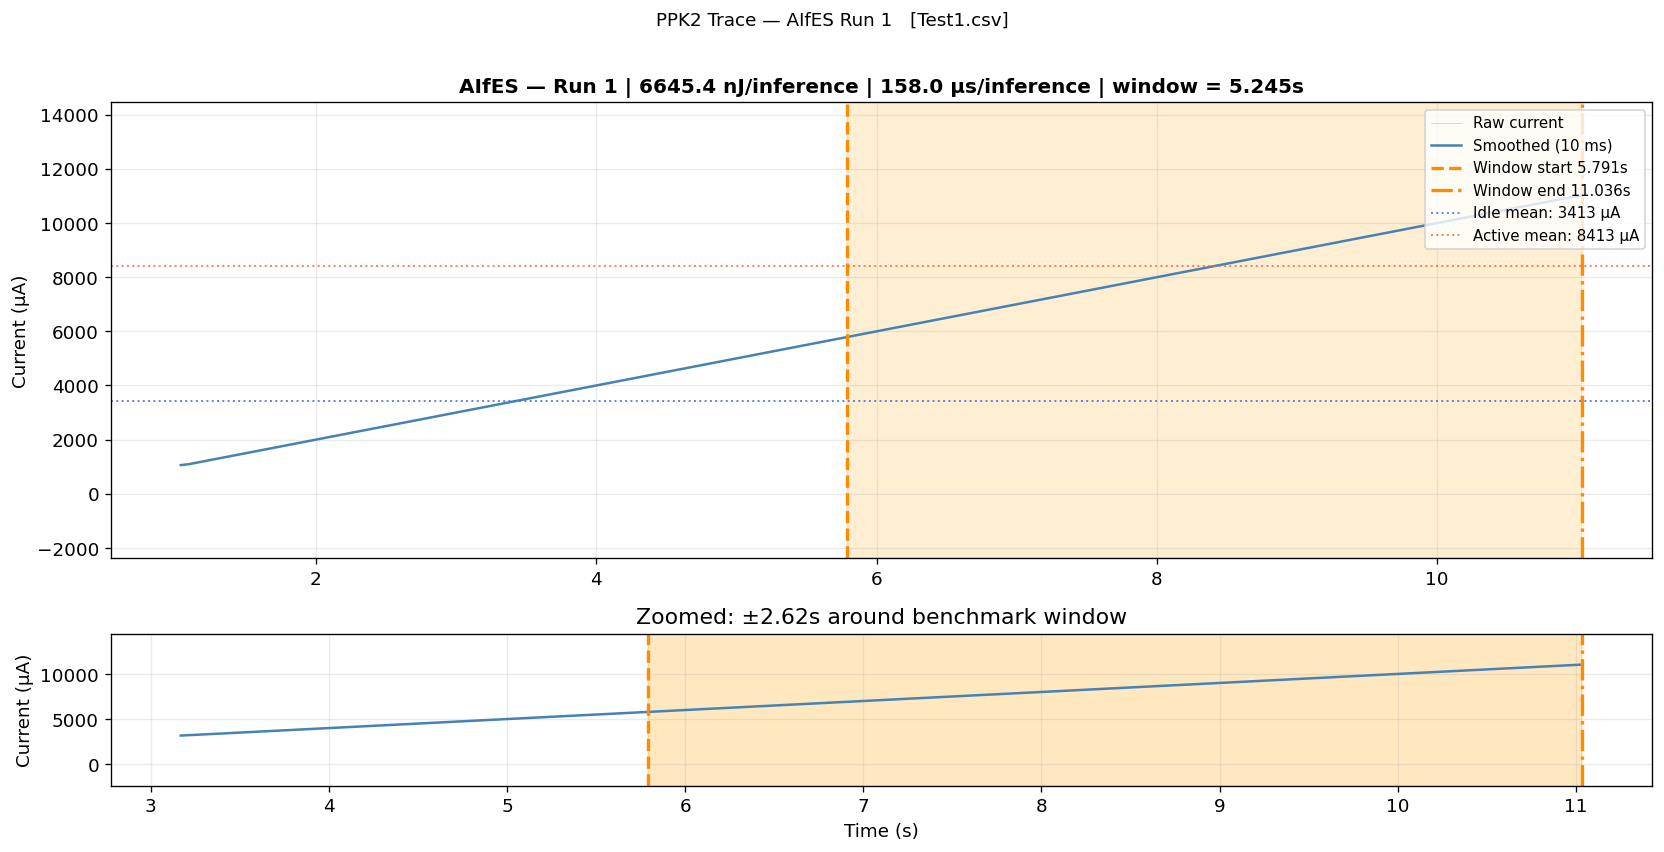

  Energy: 6645.4 nJ/inference  |  Latency: 158.0 µs/inference
  Idle mean: 3413 µA  →  Active mean: 8413 µA  (+5000 µA, +146.5%)
  Saved: ppk2_results\aifes_run1_trace.png

  Loaded 1,000,001 rows. Columns: ['timestamp(ms)', 'current(ua)', 'd0-d7']
  Timestamp unit: ms | duration: 10.00s | sample rate: 100000 Hz | current mean: 6700 uA  min: 1700  max: 11700
  Window detected: 6.555s to 11.700s  (5.145s)  [idle=5700 uA, threshold=6555 uA]


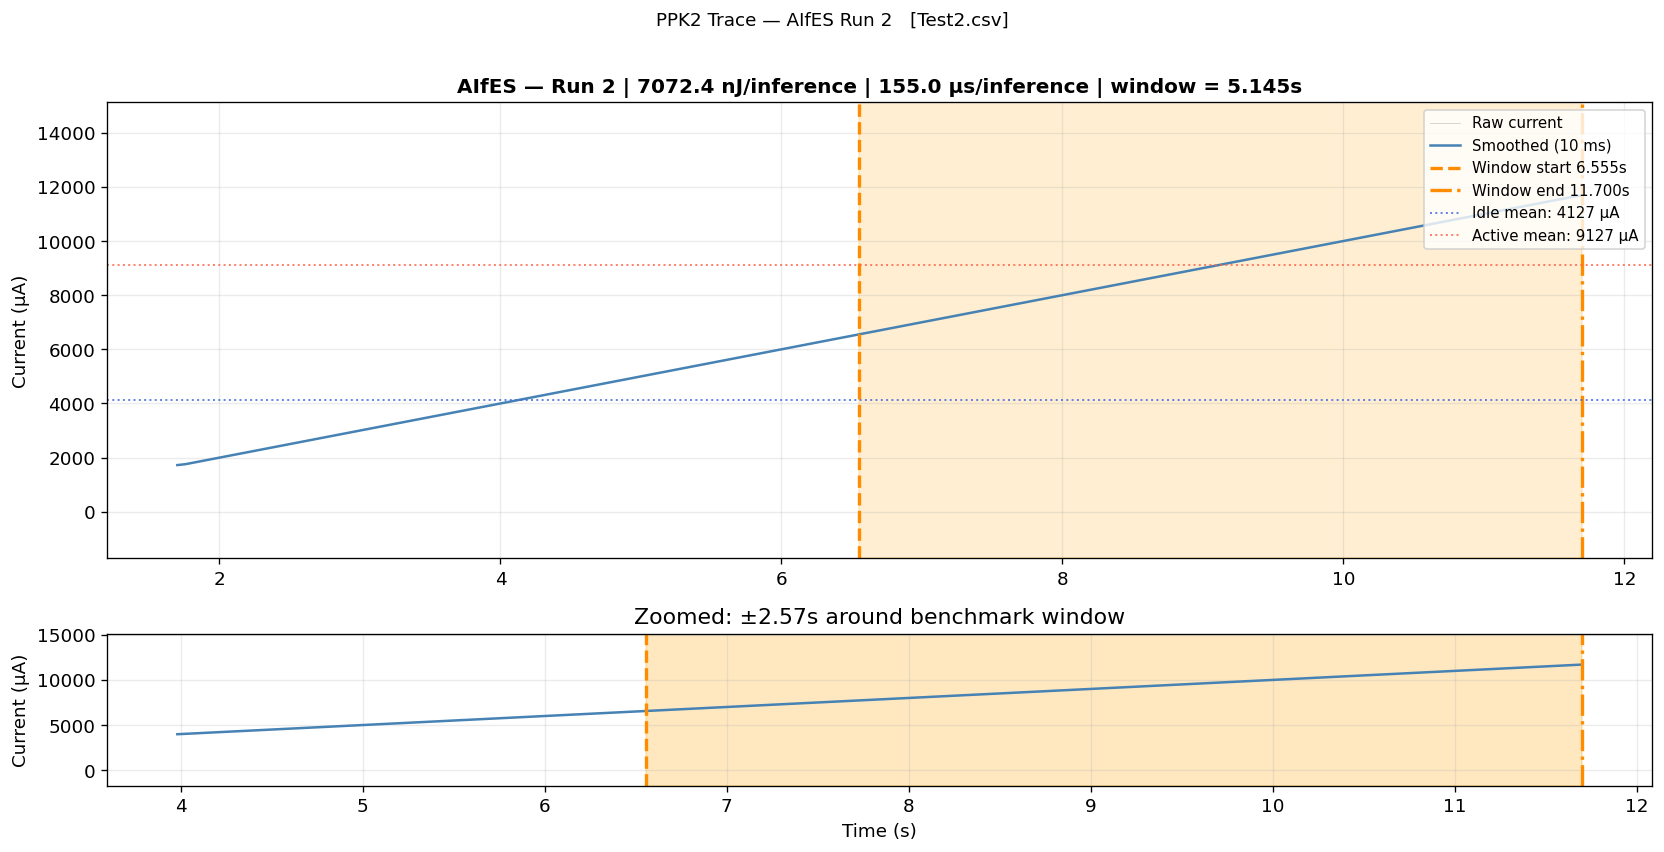

  Energy: 7072.4 nJ/inference  |  Latency: 155.0 µs/inference
  Idle mean: 4127 µA  →  Active mean: 9127 µA  (+5000 µA, +121.1%)
  Saved: ppk2_results\aifes_run2_trace.png

  Loaded 1,000,001 rows. Columns: ['timestamp(ms)', 'current(ua)', 'd0-d7']
  Timestamp unit: ms | duration: 10.00s | sample rate: 100000 Hz | current mean: 6330 uA  min: 1330  max: 11330
  Window detected: 6.130s to 11.330s  (5.200s)  [idle=5330 uA, threshold=6130 uA]


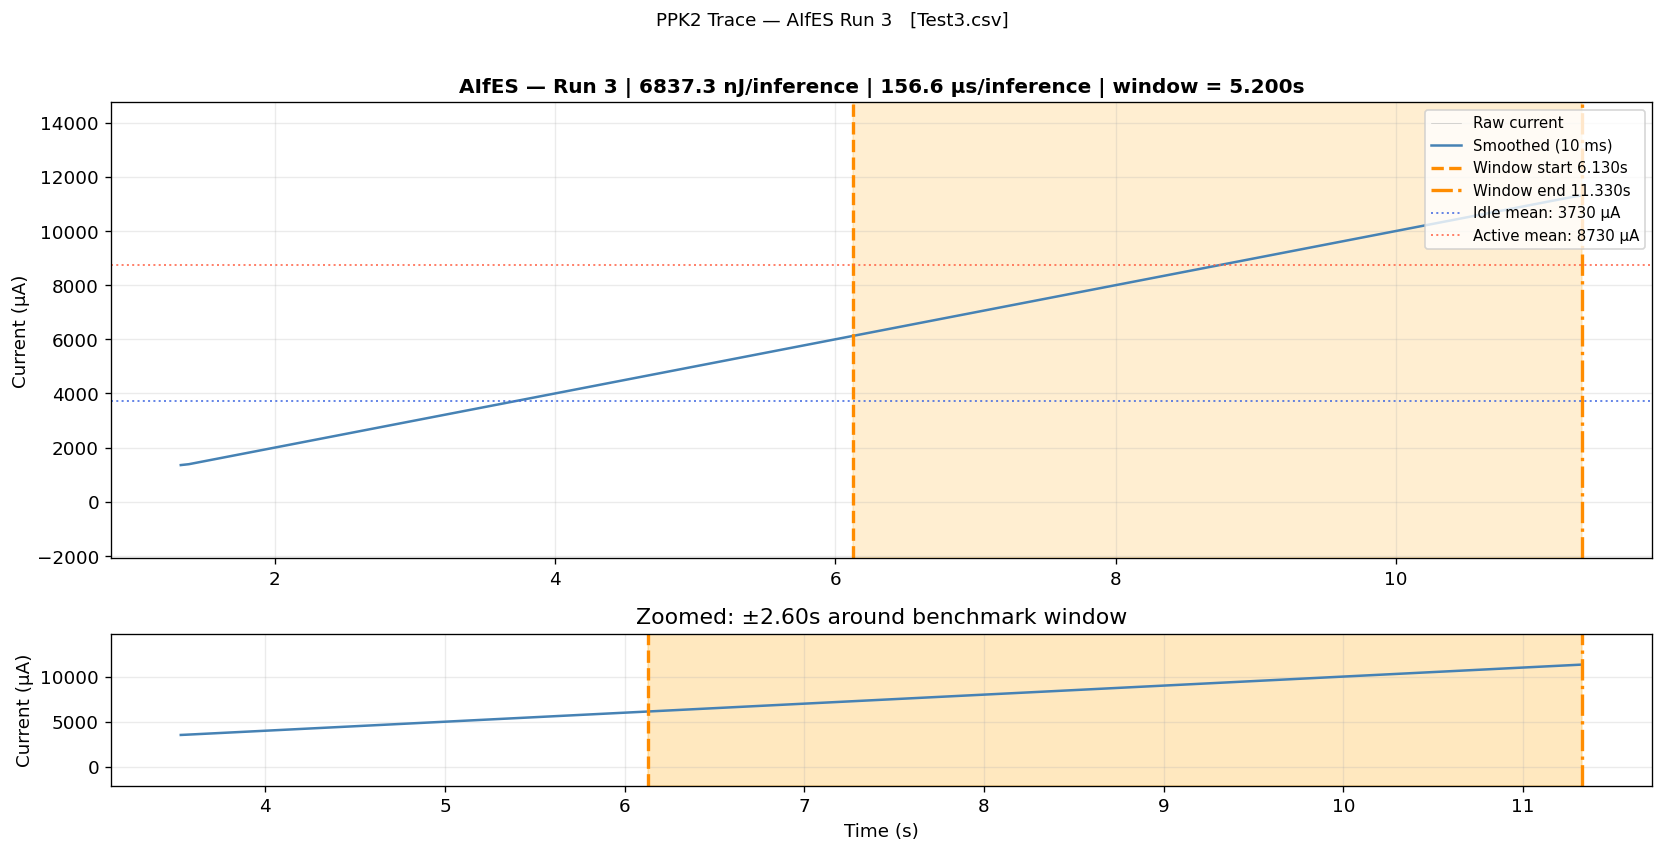

  Energy: 6837.3 nJ/inference  |  Latency: 156.6 µs/inference
  Idle mean: 3730 µA  →  Active mean: 8730 µA  (+5000 µA, +134.0%)
  Saved: ppk2_results\aifes_run3_trace.png

  Loaded 1,000,001 rows. Columns: ['timestamp(ms)', 'current(ua)', 'd0-d7']
  Timestamp unit: ms | duration: 10.00s | sample rate: 100000 Hz | current mean: 6236 uA  min: 1236  max: 11236
  Window detected: 6.022s to 11.236s  (5.215s)  [idle=5236 uA, threshold=6022 uA]


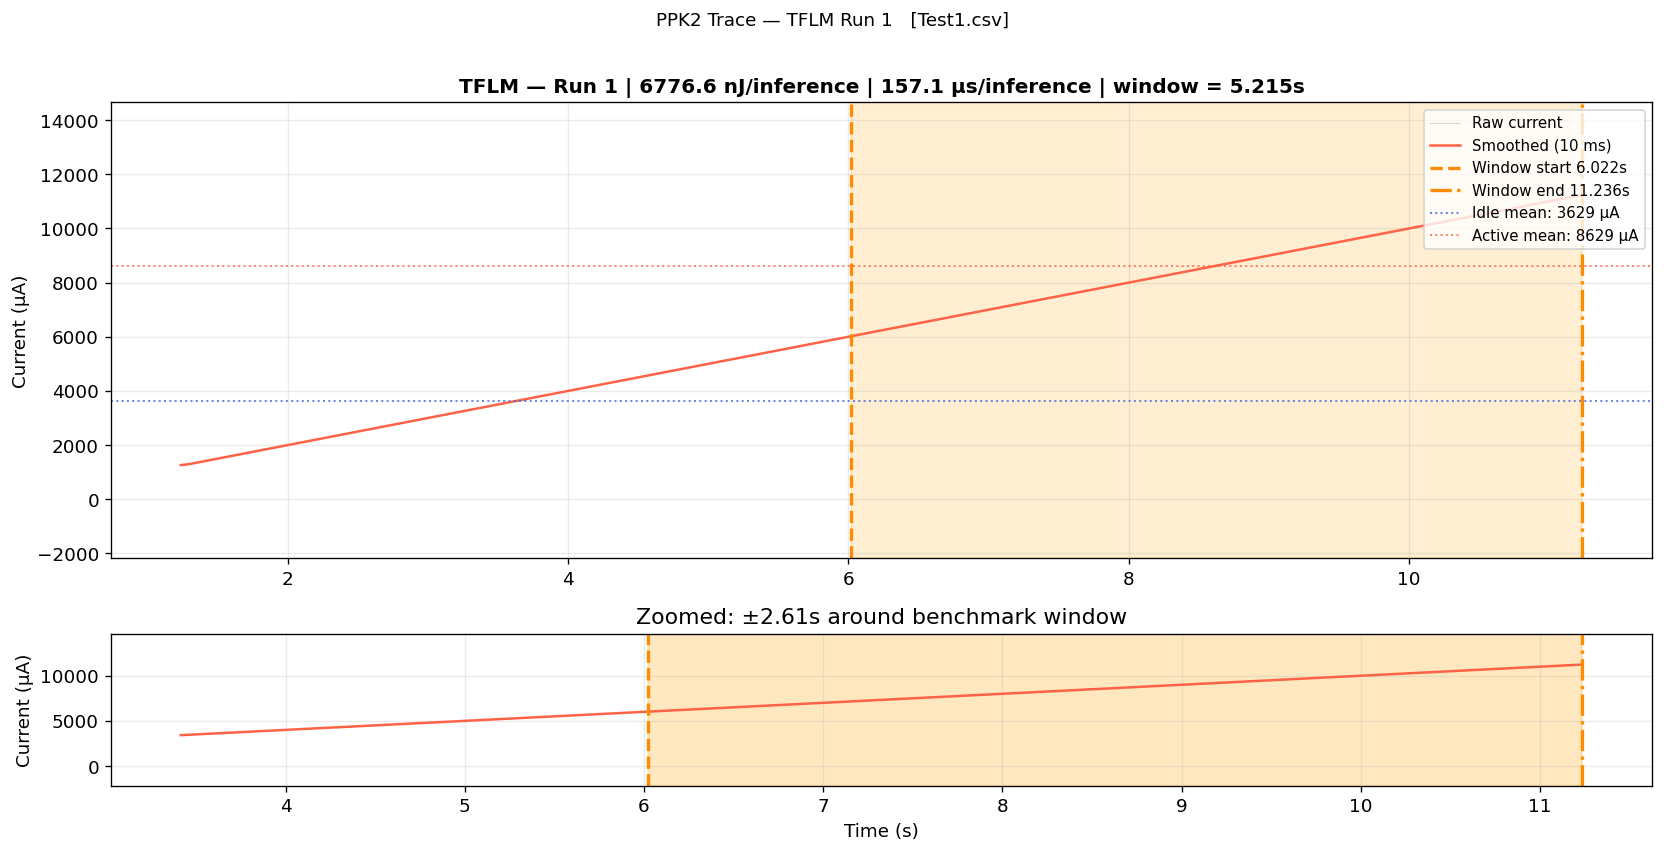

  Energy: 6776.6 nJ/inference  |  Latency: 157.1 µs/inference
  Idle mean: 3629 µA  →  Active mean: 8629 µA  (+5000 µA, +137.8%)
  Saved: ppk2_results\tflm_run1_trace.png

  Loaded 1,000,001 rows. Columns: ['timestamp(ms)', 'current(ua)', 'd0-d7']
  Timestamp unit: ms | duration: 10.00s | sample rate: 100000 Hz | current mean: 6825 uA  min: 1825  max: 11825
  Window detected: 6.699s to 11.825s  (5.126s)  [idle=5825 uA, threshold=6699 uA]


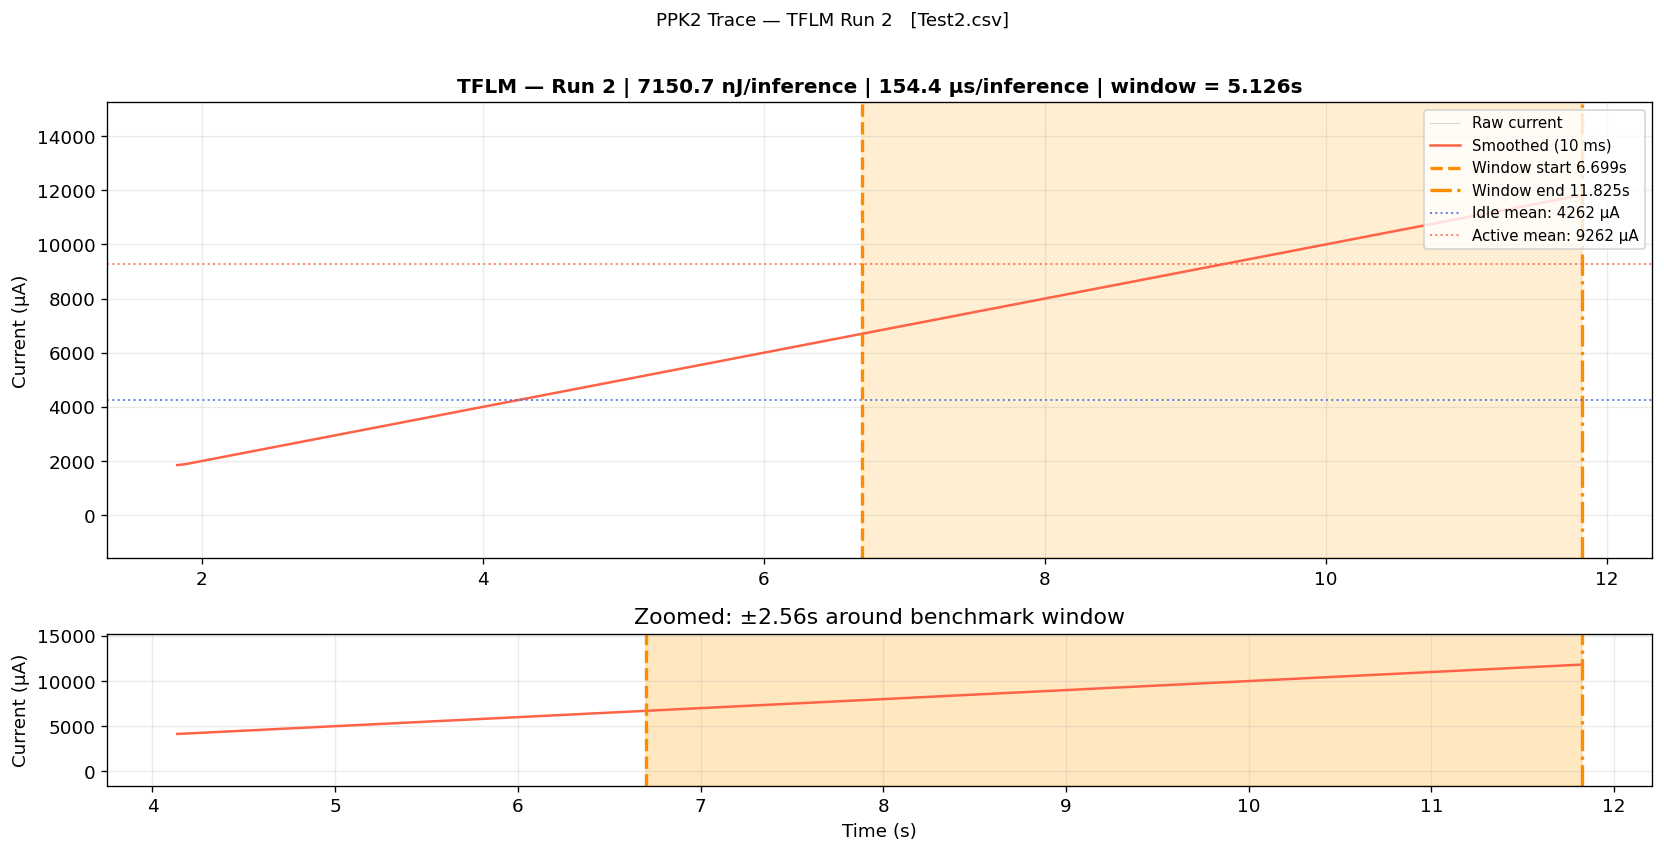

  Energy: 7150.7 nJ/inference  |  Latency: 154.4 µs/inference
  Idle mean: 4262 µA  →  Active mean: 9262 µA  (+5000 µA, +117.3%)
  Saved: ppk2_results\tflm_run2_trace.png

  Loaded 1,000,001 rows. Columns: ['timestamp(ms)', 'current(ua)', 'd0-d7']
  Timestamp unit: ms | duration: 10.00s | sample rate: 100000 Hz | current mean: 7323 uA  min: 2323  max: 12323
  Window detected: 7.271s to 12.323s  (5.052s)  [idle=6323 uA, threshold=7271 uA]


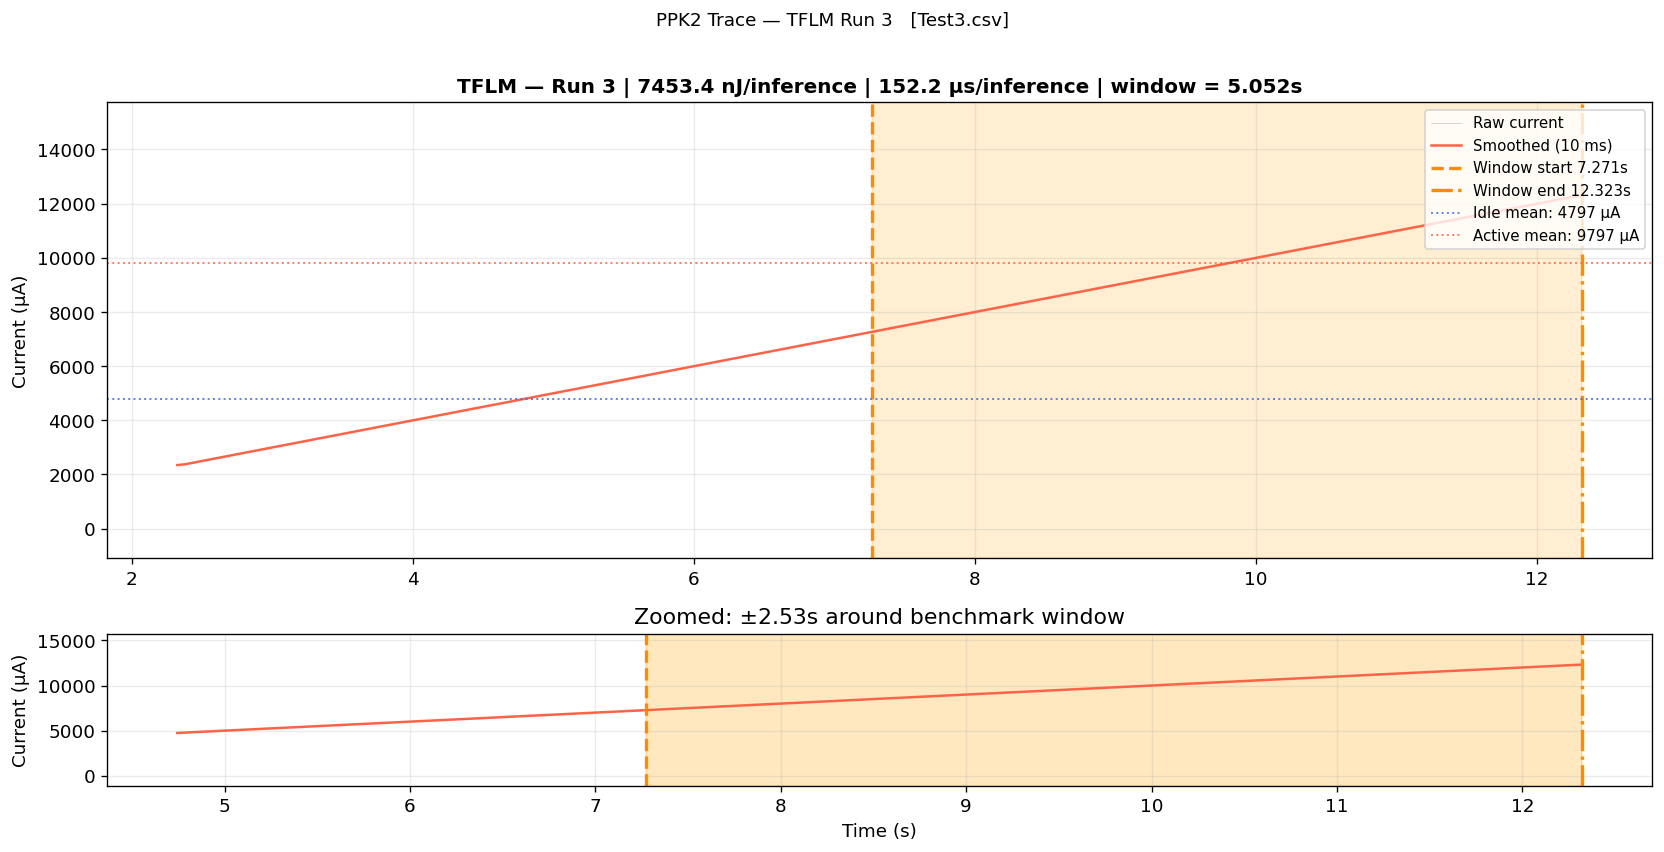

  Energy: 7453.4 nJ/inference  |  Latency: 152.2 µs/inference
  Idle mean: 4797 µA  →  Active mean: 9797 µA  (+5000 µA, +104.2%)
  Saved: ppk2_results\tflm_run3_trace.png


In [24]:
# ── AIfES traces ────────────────────────────────────────────────────────────
for i, fpath in enumerate(sorted(AIFES_DIR.glob('*.csv')), start=1):
    print(f'\n{"="*60}')
    plot_trace_with_window(fpath, framework='AIfES', run_num=i, color='steelblue')

# ── TFLM traces ─────────────────────────────────────────────────────────────
for i, fpath in enumerate(sorted(TFLM_DIR.glob('*.csv')), start=1):
    print(f'\n{"="*60}')
    plot_trace_with_window(fpath, framework='TFLM', run_num=i, color='tomato')

## 2. Load AIfES Measurements

Reading from: `C:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\ML\AlfES_Inference\`

Found 3 AIfES files:
  Test1.csv
  Test2.csv
  Test3.csv

--- Run 1: Test1.csv ---
  Loaded 1,000,001 rows. Columns: ['timestamp(ms)', 'current(ua)', 'd0-d7']
  Timestamp unit: ms | duration: 10.00s | sample rate: 100000 Hz | current mean: 6036 uA  min: 1036  max: 11036
  Window detected: 5.791s to 11.036s  (5.245s)  [idle=5036 uA, threshold=5791 uA]
  Benchmark window  : 5.245 s
  Total energy      : 220626.9 uJ
  Energy/inference  : 6645.389 nJ  (6.645389 uJ)
  Time/inference    : 158.0 us

--- Run 2: Test2.csv ---
  Loaded 1,000,001 rows. Columns: ['timestamp(ms)', 'current(ua)', 'd0-d7']
  Timestamp unit: ms | duration: 10.00s | sample rate: 100000 Hz | current mean: 6700 uA  min: 1700  max: 11700
  Window detected: 6.555s to 11.700s  (5.145s)  [idle=5700 uA, threshold=6555 uA]
  Benchmark window  : 5.145 s
  Total energy      : 234804.8 uJ
  Energy/inference  : 7072.434 nJ  (7.072434 uJ)
  Time/inference    : 155.0 us

--- Run 3: Test3.csv ---
  Loaded 1,000,001 rows. Columns: ['t

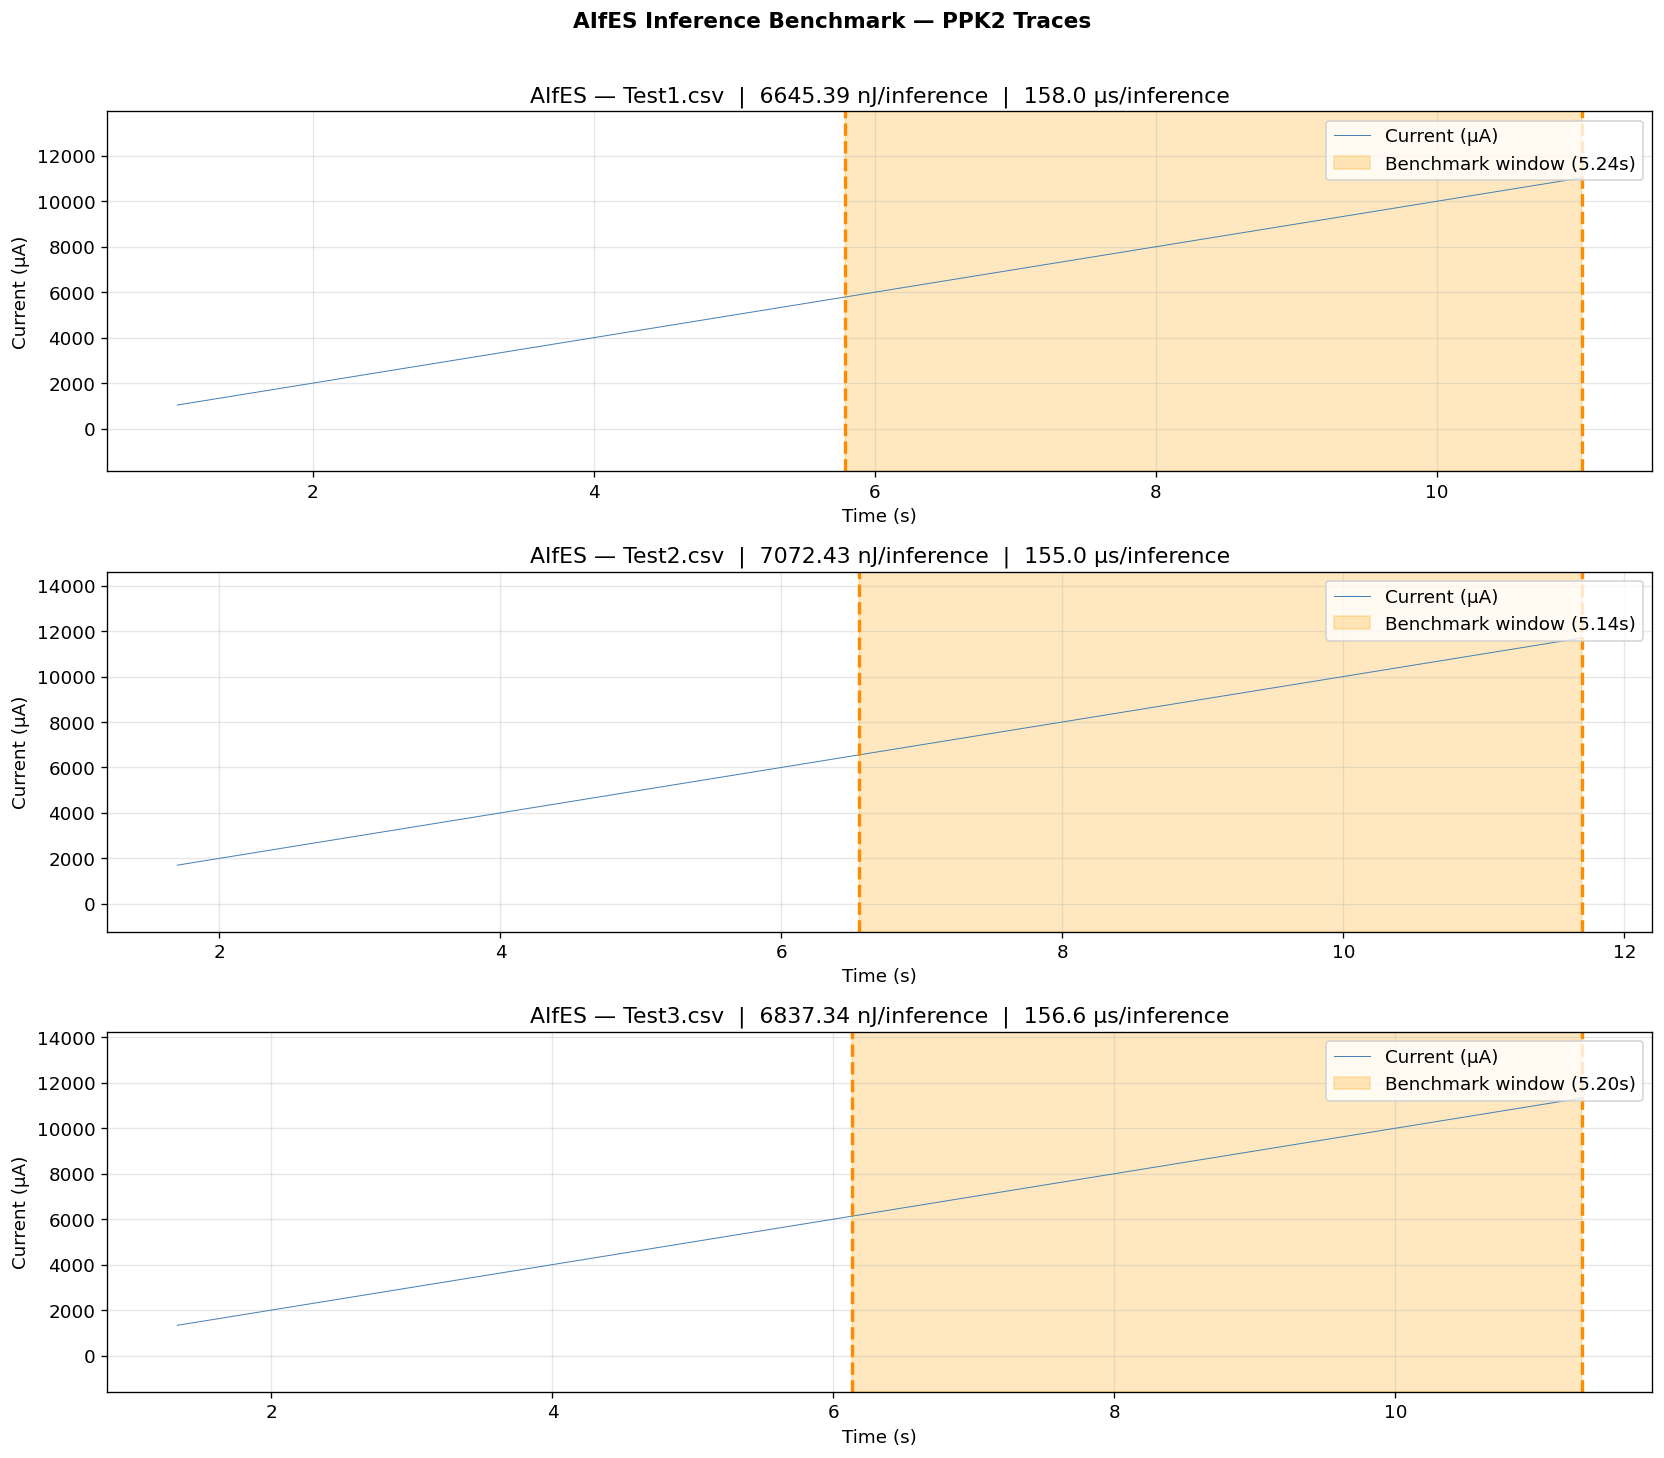


Plot saved to ppk2_results/aifes_traces.png


In [25]:
aifes_files = sorted(AIFES_DIR.glob('*.csv'))
print(f'Found {len(aifes_files)} AIfES files:')
for f in aifes_files:
    print(f'  {f.name}')

aifes_results = []

fig, axes = plt.subplots(len(aifes_files), 1, figsize=(14, 4 * len(aifes_files)), squeeze=False)

for idx, fpath in enumerate(aifes_files):
    print(f'\n--- Run {idx+1}: {fpath.name} ---')
    df = load_ppk2_csv(fpath)
    t_start, t_end = detect_benchmark_window(df)

    energy_uJ         = calc_energy_uJ(df, t_start, t_end)
    energy_per_inf_uJ = energy_uJ / N_INFERENCES
    energy_per_inf_nJ = energy_per_inf_uJ * 1000
    window_s          = t_end - t_start
    us_per_inf        = (window_s * 1e6) / N_INFERENCES

    aifes_results.append({
        'run': idx + 1,
        'file': fpath.name,
        'window_s': window_s,
        'total_energy_uJ': energy_uJ,
        'energy_per_inf_uJ': energy_per_inf_uJ,
        'energy_per_inf_nJ': energy_per_inf_nJ,
        'us_per_inf': us_per_inf,
    })

    print(f'  Benchmark window  : {window_s:.3f} s')
    print(f'  Total energy      : {energy_uJ:.1f} uJ')
    print(f'  Energy/inference  : {energy_per_inf_nJ:.3f} nJ  ({energy_per_inf_uJ:.6f} uJ)')
    print(f'  Time/inference    : {us_per_inf:.1f} us')

    ax = axes[idx][0]
    # Downsample for plotting speed (every 20th point = 5000 Hz, still clear)
    ds = df.iloc[::20]
    ax.plot(ds['time_s'], ds['current_uA'], lw=0.6, color='steelblue', label='Current (µA)')
    ax.axvspan(t_start, t_end, alpha=0.25, color='orange', label=f'Benchmark window ({window_s:.2f}s)')
    ax.axvline(t_start, color='darkorange', lw=2, ls='--')
    ax.axvline(t_end,   color='darkorange', lw=2, ls='--')
    ax.set_title(f'AIfES — {fpath.name}  |  {energy_per_inf_nJ:.2f} nJ/inference  |  {us_per_inf:.1f} µs/inference')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Current (µA)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    # Zoom y-axis to the actual signal range so the benchmark box is clearly visible
    y_lo = df['current_uA'].quantile(0.005)
    y_hi = df['current_uA'].quantile(0.995)
    margin = (y_hi - y_lo) * 0.3
    ax.set_ylim(y_lo - margin, y_hi + margin)

plt.suptitle('AIfES Inference Benchmark — PPK2 Traces', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'aifes_traces.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'\nPlot saved to {RESULTS_DIR}/aifes_traces.png')

## 3. Load TF Lite Micro Measurements

Reading from: `C:\Users\cmahe\OneDrive\Desktop\SSE Masters\Thesis\PPK2 Data\CSV\ML\Tensorflow_Lite\`

Found 3 TFLM files:
  Test1.csv
  Test2.csv
  Test3.csv

--- Run 1: Test1.csv ---
  Loaded 1,000,001 rows. Columns: ['timestamp(ms)', 'current(ua)', 'd0-d7']
  Timestamp unit: ms | duration: 10.00s | sample rate: 100000 Hz | current mean: 6236 uA  min: 1236  max: 11236
  Window detected: 6.022s to 11.236s  (5.215s)  [idle=5236 uA, threshold=6022 uA]
  Benchmark window  : 5.215 s
  Total energy      : 224983.5 uJ
  Energy/inference  : 6776.613 nJ  (6.776613 uJ)
  Time/inference    : 157.1 us

--- Run 2: Test2.csv ---
  Loaded 1,000,001 rows. Columns: ['timestamp(ms)', 'current(ua)', 'd0-d7']
  Timestamp unit: ms | duration: 10.00s | sample rate: 100000 Hz | current mean: 6825 uA  min: 1825  max: 11825
  Window detected: 6.699s to 11.825s  (5.126s)  [idle=5825 uA, threshold=6699 uA]
  Benchmark window  : 5.126 s
  Total energy      : 237403.2 uJ
  Energy/inference  : 7150.698 nJ  (7.150698 uJ)
  Time/inference    : 154.4 us

--- Run 3: Test3.csv ---
  Loaded 1,000,001 rows. Columns: ['ti

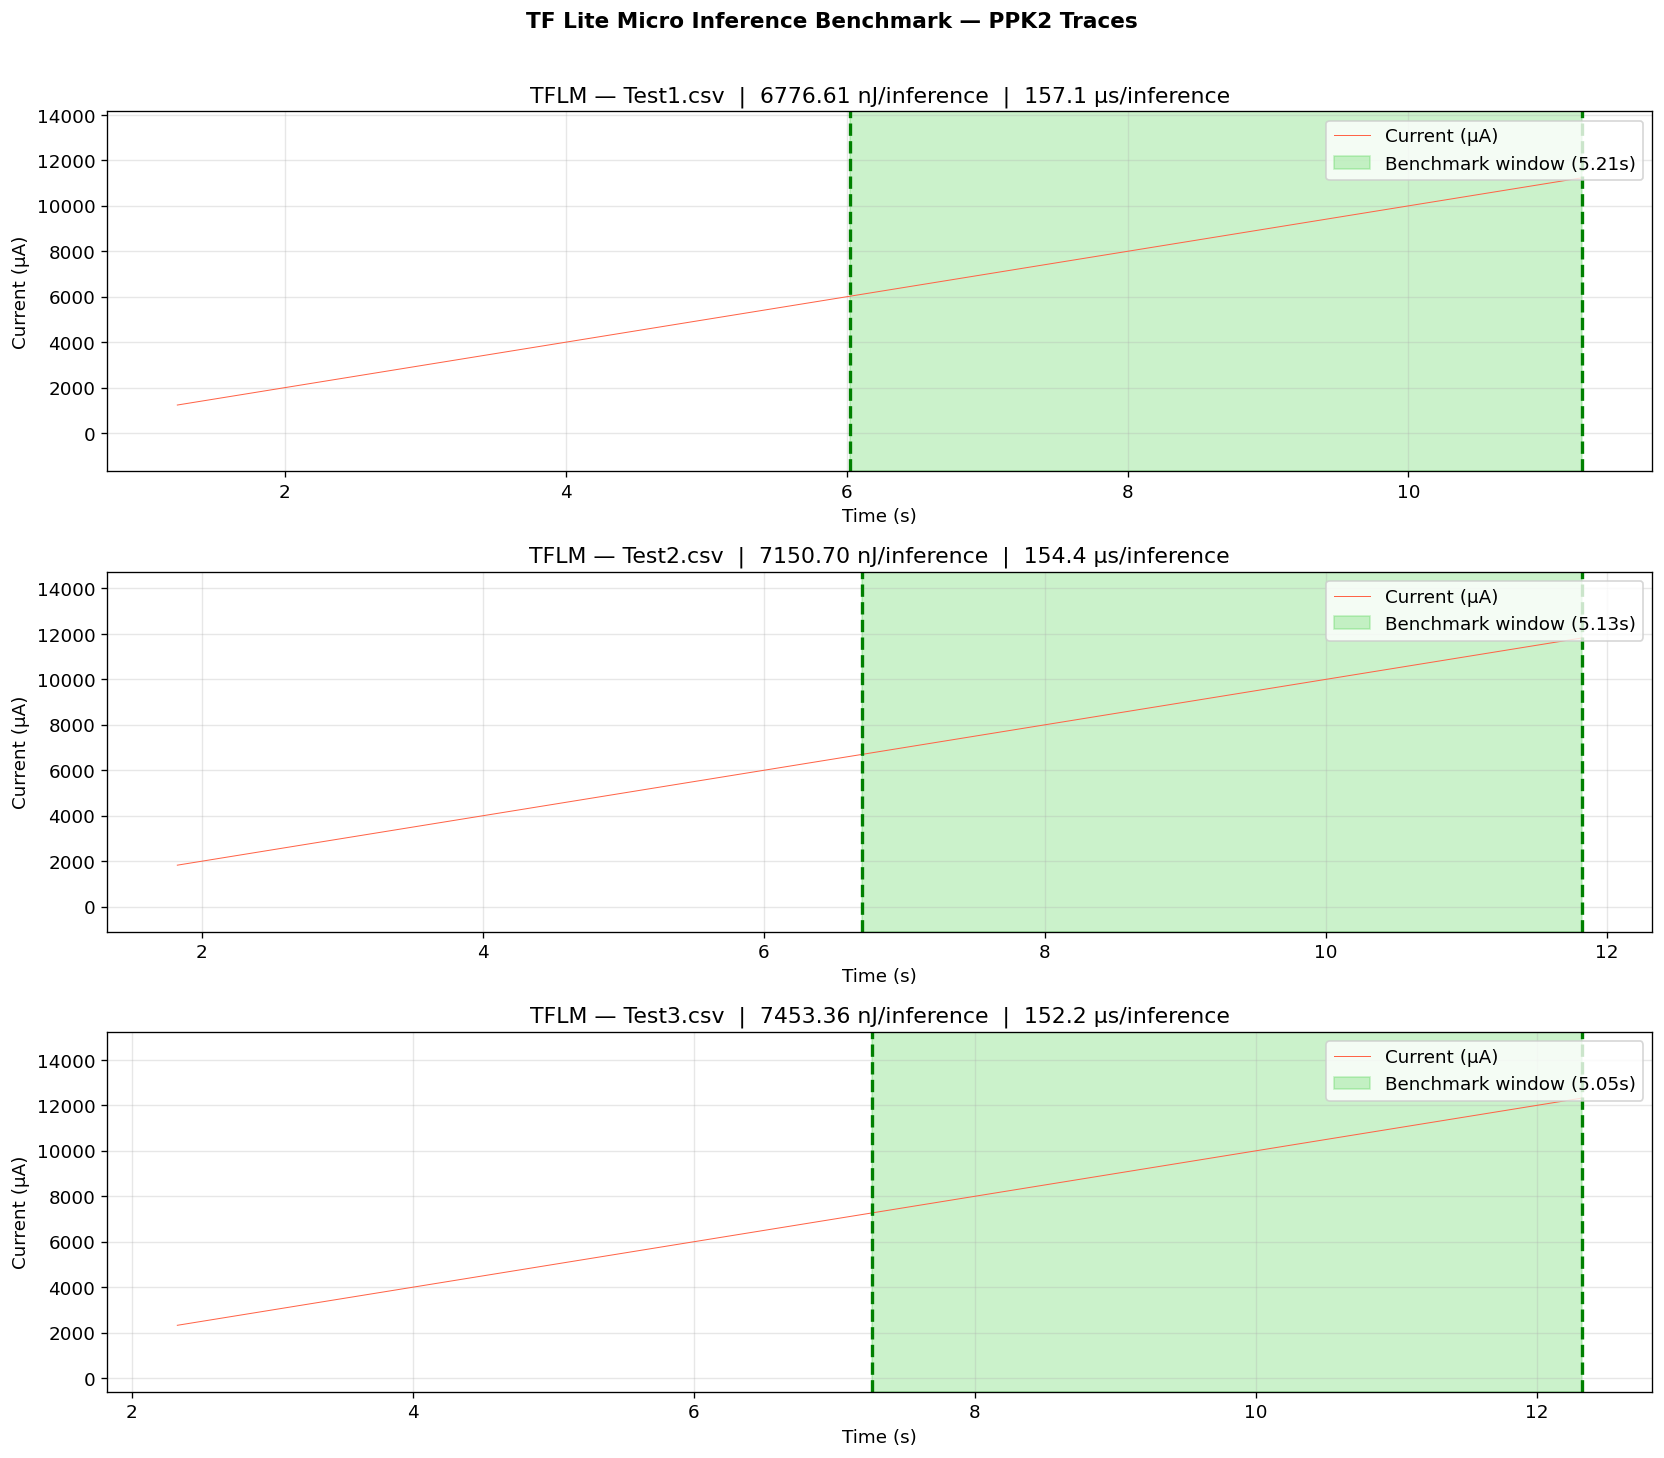


Plot saved to ppk2_results/tflm_traces.png


In [26]:
tflm_files = sorted(TFLM_DIR.glob('*.csv'))
print(f'Found {len(tflm_files)} TFLM files:')
for f in tflm_files:
    print(f'  {f.name}')

tflm_results = []

fig, axes = plt.subplots(len(tflm_files), 1, figsize=(14, 4 * len(tflm_files)), squeeze=False)

for idx, fpath in enumerate(tflm_files):
    print(f'\n--- Run {idx+1}: {fpath.name} ---')
    df = load_ppk2_csv(fpath)
    t_start, t_end = detect_benchmark_window(df)

    energy_uJ         = calc_energy_uJ(df, t_start, t_end)
    energy_per_inf_uJ = energy_uJ / N_INFERENCES
    energy_per_inf_nJ = energy_per_inf_uJ * 1000
    window_s          = t_end - t_start
    us_per_inf        = (window_s * 1e6) / N_INFERENCES

    tflm_results.append({
        'run': idx + 1,
        'file': fpath.name,
        'window_s': window_s,
        'total_energy_uJ': energy_uJ,
        'energy_per_inf_uJ': energy_per_inf_uJ,
        'energy_per_inf_nJ': energy_per_inf_nJ,
        'us_per_inf': us_per_inf,
    })

    print(f'  Benchmark window  : {window_s:.3f} s')
    print(f'  Total energy      : {energy_uJ:.1f} uJ')
    print(f'  Energy/inference  : {energy_per_inf_nJ:.3f} nJ  ({energy_per_inf_uJ:.6f} uJ)')
    print(f'  Time/inference    : {us_per_inf:.1f} us')

    ax = axes[idx][0]
    # Downsample for plotting speed (every 20th point = 5000 Hz, still clear)
    ds = df.iloc[::20]
    ax.plot(ds['time_s'], ds['current_uA'], lw=0.6, color='tomato', label='Current (µA)')
    ax.axvspan(t_start, t_end, alpha=0.25, color='limegreen', label=f'Benchmark window ({window_s:.2f}s)')
    ax.axvline(t_start, color='green', lw=2, ls='--')
    ax.axvline(t_end,   color='green', lw=2, ls='--')
    ax.set_title(f'TFLM — {fpath.name}  |  {energy_per_inf_nJ:.2f} nJ/inference  |  {us_per_inf:.1f} µs/inference')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Current (µA)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    # Zoom y-axis to the actual signal range so the benchmark box is clearly visible
    y_lo = df['current_uA'].quantile(0.005)
    y_hi = df['current_uA'].quantile(0.995)
    margin = (y_hi - y_lo) * 0.3
    ax.set_ylim(y_lo - margin, y_hi + margin)

plt.suptitle('TF Lite Micro Inference Benchmark — PPK2 Traces', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tflm_traces.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'\nPlot saved to {RESULTS_DIR}/tflm_traces.png')

## 4. Comparison Summary

In [27]:
# Build summary DataFrames
aifes_df = pd.DataFrame(aifes_results)
tflm_df  = pd.DataFrame(tflm_results)

print('=== AIfES Results ===')
print(aifes_df[['run','window_s','total_energy_uJ','energy_per_inf_nJ','us_per_inf']].to_string(index=False))
print(f'  Mean energy/inference: {aifes_df["energy_per_inf_nJ"].mean():.3f} ± {aifes_df["energy_per_inf_nJ"].std():.3f} nJ')

print('\n=== TF Lite Micro Results ===')
print(tflm_df[['run','window_s','total_energy_uJ','energy_per_inf_nJ','us_per_inf']].to_string(index=False))
print(f'  Mean energy/inference: {tflm_df["energy_per_inf_nJ"].mean():.3f} ± {tflm_df["energy_per_inf_nJ"].std():.3f} nJ')

aifes_mean_nJ = aifes_df['energy_per_inf_nJ'].mean()
tflm_mean_nJ  = tflm_df['energy_per_inf_nJ'].mean()
ratio = aifes_mean_nJ / tflm_mean_nJ if tflm_mean_nJ > 0 else float('nan')

aifes_mean_us = aifes_df['us_per_inf'].mean()
tflm_mean_us  = tflm_df['us_per_inf'].mean()

print(f'\n=== Head-to-Head ===')
print(f'  AIfES (float32):  {aifes_mean_nJ:.2f} nJ/inference,  {aifes_mean_us:.1f} us/inference')
print(f'  TFLM  (INT8):     {tflm_mean_nJ:.2f} nJ/inference,  {tflm_mean_us:.1f} us/inference')
print(f'  Ratio AIfES/TFLM: {ratio:.2f}x  (>1 means AIfES uses more energy)')

=== AIfES Results ===
 run  window_s  total_energy_uJ  energy_per_inf_nJ  us_per_inf
   1   5.24463    220626.899136        6645.388528  157.970783
   2   5.14500    234804.808875        7072.434002  154.969880
   3   5.20046    226999.688965        6837.340029  156.640361
  Mean energy/inference: 6851.721 ± 213.886 nJ

=== TF Lite Micro Results ===
 run  window_s  total_energy_uJ  energy_per_inf_nJ  us_per_inf
   1   5.21454    224983.544480        6776.612786  157.064458
   2   5.12617    237403.185040        7150.698345  154.402711
   3   5.05157    247451.661607        7453.363301  152.155723
  Mean energy/inference: 7126.891 ± 339.003 nJ

=== Head-to-Head ===
  AIfES (float32):  6851.72 nJ/inference,  156.5 us/inference
  TFLM  (INT8):     7126.89 nJ/inference,  154.5 us/inference
  Ratio AIfES/TFLM: 0.96x  (>1 means AIfES uses more energy)


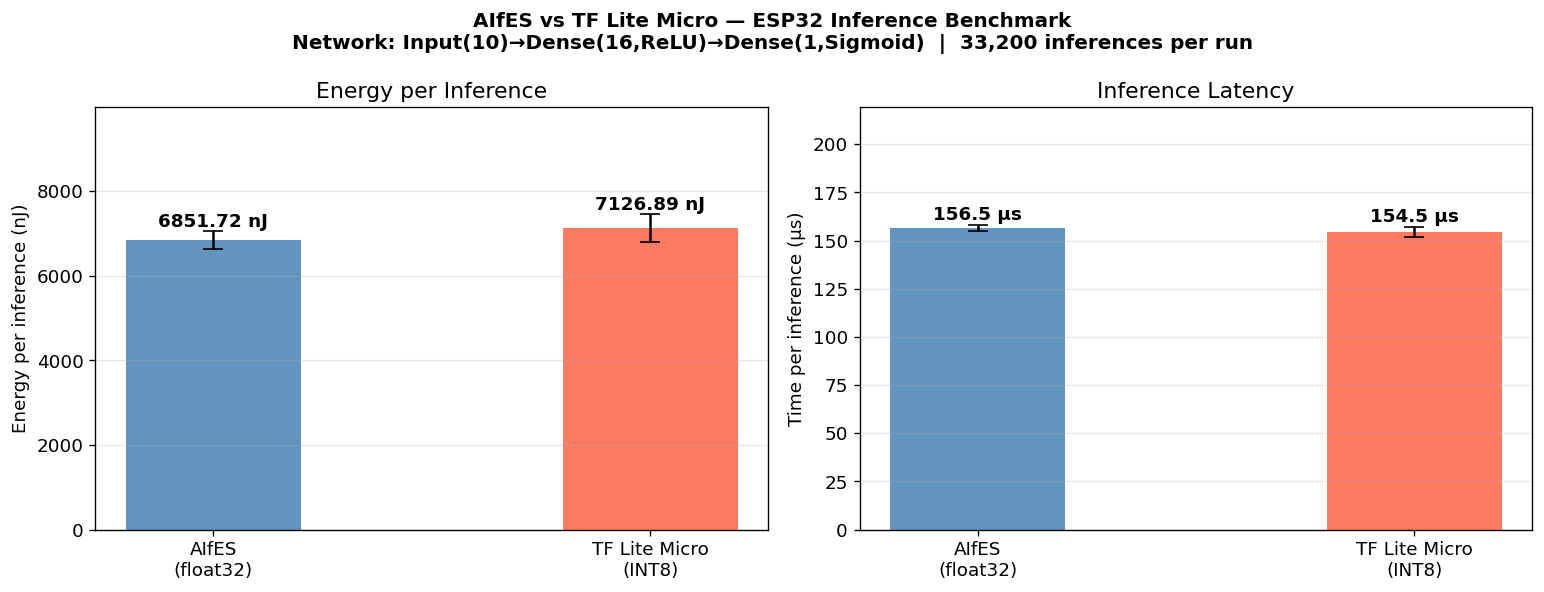

Plot saved to ppk2_results/inference_comparison.png


In [28]:
# --- Thesis comparison plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

frameworks = ['AIfES\n(float32)', 'TF Lite Micro\n(INT8)']
colors     = ['steelblue', 'tomato']

# Energy per inference
ax = axes[0]
means  = [aifes_df['energy_per_inf_nJ'].mean(),  tflm_df['energy_per_inf_nJ'].mean()]
stds   = [aifes_df['energy_per_inf_nJ'].std(),   tflm_df['energy_per_inf_nJ'].std()]
bars = ax.bar(frameworks, means, yerr=stds, color=colors, capsize=6, width=0.4, alpha=0.85)
for bar, val, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.1,
            f'{val:.2f} nJ', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Energy per inference (nJ)')
ax.set_title('Energy per Inference')
ax.set_ylim(0, max(means) * 1.4)
ax.grid(axis='y', alpha=0.3)

# Time per inference
ax = axes[1]
means_us = [aifes_df['us_per_inf'].mean(), tflm_df['us_per_inf'].mean()]
stds_us  = [aifes_df['us_per_inf'].std(),  tflm_df['us_per_inf'].std()]
bars = ax.bar(frameworks, means_us, yerr=stds_us, color=colors, capsize=6, width=0.4, alpha=0.85)
for bar, val, std in zip(bars, means_us, stds_us):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.5,
            f'{val:.1f} µs', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Time per inference (µs)')
ax.set_title('Inference Latency')
ax.set_ylim(0, max(means_us) * 1.4)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('AIfES vs TF Lite Micro — ESP32 Inference Benchmark\n'
             f'Network: Input(10)→Dense(16,ReLU)→Dense(1,Sigmoid)  |  {N_INFERENCES:,} inferences per run',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'inference_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Plot saved to {RESULTS_DIR}/inference_comparison.png')

In [29]:
# --- Thesis summary table ---
summary = pd.DataFrame({
    'Framework':         ['AIfES (float32)', 'TF Lite Micro (INT8)'],
    'Data type':         ['float32', 'INT8'],
    'Model size':        ['193 × 4B = 772 B', '~2.5 KB (quantised flatbuffer)'],
    'Energy/inf (nJ)':   [f"{aifes_df['energy_per_inf_nJ'].mean():.2f} ± {aifes_df['energy_per_inf_nJ'].std():.2f}",
                          f"{tflm_df['energy_per_inf_nJ'].mean():.2f} ± {tflm_df['energy_per_inf_nJ'].std():.2f}"],
    'Latency/inf (µs)':  [f"{aifes_df['us_per_inf'].mean():.1f} ± {aifes_df['us_per_inf'].std():.1f}",
                          f"{tflm_df['us_per_inf'].mean():.1f} ± {tflm_df['us_per_inf'].std():.1f}"],
    'Runs measured':     [len(aifes_df), len(tflm_df)],
})

aifes_mean_nJ = aifes_df['energy_per_inf_nJ'].mean()
tflm_mean_nJ  = tflm_df['energy_per_inf_nJ'].mean()
ratio = aifes_mean_nJ / tflm_mean_nJ if tflm_mean_nJ > 0 else float('nan')
winner = 'TFLM (INT8) uses less energy' if tflm_mean_nJ < aifes_mean_nJ else 'AIfES (float32) uses less energy'

print('=== Thesis Summary Table ===')
print(summary.to_string(index=False))
print(f'\nEnergy ratio  AIfES / TFLM : {ratio:.2f}x')
print(f'Result        : {winner}')
print(f'\nAIfES  mean latency: {aifes_df["us_per_inf"].mean():.1f} µs/inference')
print(f'TFLM   mean latency: {tflm_df["us_per_inf"].mean():.1f} µs/inference')

summary.to_csv(RESULTS_DIR / 'inference_summary.csv', index=False)
print(f'\nSaved to {RESULTS_DIR}/inference_summary.csv')

=== Thesis Summary Table ===
           Framework Data type                     Model size  Energy/inf (nJ) Latency/inf (µs)  Runs measured
     AIfES (float32)   float32               193 × 4B = 772 B 6851.72 ± 213.89      156.5 ± 1.5              3
TF Lite Micro (INT8)      INT8 ~2.5 KB (quantised flatbuffer) 7126.89 ± 339.00      154.5 ± 2.5              3

Energy ratio  AIfES / TFLM : 0.96x
Result        : AIfES (float32) uses less energy

AIfES  mean latency: 156.5 µs/inference
TFLM   mean latency: 154.5 µs/inference

Saved to ppk2_results/inference_summary.csv


## 5. Manual Window Override

If the auto-detection picked the wrong window for any file, override it here.
Look at the trace plots above and note the time of the LED-on step.

In [30]:
# Example: manually recompute energy for AIfES run 1 with a specific window
# Uncomment and set times as needed after inspecting the trace plots

# MANUAL_AIFES_WINDOWS = [
#     (3.5, 5.8),   # run 1: t_start, t_end in seconds
#     (3.4, 5.7),   # run 2
#     (3.6, 5.9),   # run 3
# ]

# for idx, (t0, t1) in enumerate(MANUAL_AIFES_WINDOWS):
#     df = load_ppk2_csv(aifes_files[idx])
#     e = calc_energy_uJ(df, t0, t1)
#     nJ = (e / N_INFERENCES) * 1000
#     print(f'AIfES run {idx+1} manual: {nJ:.3f} nJ/inference  (window {t1-t0:.3f}s)')

print('Manual override cell ready — uncomment if needed.')

Manual override cell ready — uncomment if needed.
